In [2]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np

# ===================================================
# STEP 1: Load the three files
# ===================================================

counts = pd.read_excel("PD-COUNT-FILE.xlsx")        # raw counts, GENE ID + sample columns
sample = pd.read_excel("PD-SAMPLE-FILE.xlsx")        # COUNT (sample id) + STATUS
deg    = pd.read_excel("PD_DEG.xlsx")                # ENTREZID, SYMBOL, GENENAME, logFC, adj.P.Val etc.

print(counts.shape, sample.shape, deg.shape)
counts.head()
sample.head()
deg.head()

Saving PD-COUNT-FILE.xlsx to PD-COUNT-FILE.xlsx
Saving PD-SAMPLE-FILE.xlsx to PD-SAMPLE-FILE.xlsx
Saving PD_DEG.xlsx to PD_DEG.xlsx
(39376, 73) (72, 2) (430, 10)


,ENTREZID,ENSEMBL,SYMBOL,GENENAME,logFC,AveExpr,t,P.Value,adj.P.Val,B
0,80332,ENSG00000149451,ADAM33,ADAM metallopeptidase domain 33,1.168408,4.071609,6.744653,2.931907e-09,0.000024,10.951319
1,147912,ENSG00000177045,SIX5,SIX homeobox 5,1.110387,2.221554,6.545832,6.824815e-09,0.000024,10.027495
2,3315,ENSG00000106211,HSPB1,heat shock protein family B (small) member 1,1.691442,7.062615,6.496767,8.399876e-09,0.000024,9.943526
3,140876,ENSG00000042062,RIPOR3,RIPOR family member 3,1.345395,2.133005,6.341077,1.619431e-08,0.000024,9.222578
4,23615,ENSG00000290671,PYY2,peptide YY 2 (pseudogene),1.416601,-0.447972,6.328158,1.709784e-08,0.000024,8.591716


In [3]:
# ===================================================
# STEP 2: Clean the DEG list
# Drop NA Entrez, LOC*, pseudogenes, MIR*, SNOR*, LINC* (optional)
# ===================================================

deg_clean = deg.copy()

deg_clean = deg_clean[deg_clean["ENTREZID"].notna()]

In [4]:
deg_clean = deg_clean[~deg_clean["SYMBOL"].astype(str).str.startswith("LOC")]
deg_clean = deg_clean[~deg_clean["GENENAME"].astype(str).str.contains("pseudogene", case=False, na=False)]
deg_clean = deg_clean[~deg_clean["SYMBOL"].astype(str).str.startswith("MIR")]
deg_clean = deg_clean[~deg_clean["SYMBOL"].astype(str).str.startswith("SNOR")]

print(f"DEGs before cleaning: {deg.shape[0]}")
print(f"DEGs after cleaning:  {deg_clean.shape[0]}")

removed = deg[~deg["ENTREZID"].isin(deg_clean["ENTREZID"])]
removed[["ENTREZID", "SYMBOL", "GENENAME"]]

DEGs before cleaning: 430
DEGs after cleaning:  351


,ENTREZID,SYMBOL,GENENAME
4,23615,PYY2,peptide YY 2 (pseudogene)
14,101928156,LOC101928156,uncharacterized LOC101928156
24,4500,MT1L,metallothionein 1L (pseudogene)
30,105375022,LOC105375022,uncharacterized LOC105375022
34,348645,MIR3667HG,MIR3667 host gene
...,...,...,...
390,107986182,LOC107986182,uncharacterized LOC107986182
400,101929348,LOC101929348,uncharacterized LOC101929348
411,101929473,LOC101929473,uncharacterized LOC101929473
417,105377696,LOC105377696,uncharacterized LOC105377696


In [5]:
# ===================================================
# STEP 3: Subset raw counts to cleaned DEG genes
# ===================================================

counts_indexed = counts.set_index("GENE ID")

clean_entrez_ids = deg_clean["ENTREZID"].astype(int).tolist()

available_ids = [g for g in clean_entrez_ids if g in counts_indexed.index]
missing_ids   = [g for g in clean_entrez_ids if g not in counts_indexed.index]

print(f"DEGs found in count matrix: {len(available_ids)}")
print(f"DEGs missing from count matrix: {len(missing_ids)}")

counts_sub = counts_indexed.loc[available_ids]
counts_sub.shape

# ===================================================
# STEP 4: Normalize (CPM + log2), since this is raw counts
# ===================================================

lib_sizes = counts_indexed.sum(axis=0)   # total counts per sample across ALL genes

cpm = counts_sub.divide(lib_sizes, axis=1) * 1e6
log_cpm = np.log2(cpm + 1)

log_cpm.head()

# ===================================================
# STEP 5: Merge with sample metadata
# ===================================================

expr_mat = log_cpm.T
expr_mat.index.name = "SampleID"
expr_mat = expr_mat.reset_index()

sample_clean = sample.rename(columns={"COUNT": "SampleID"})

df_ml = expr_mat.merge(sample_clean[["SampleID", "STATUS"]], on="SampleID", how="inner")
df_ml = df_ml.set_index("SampleID")

print(df_ml.shape)
df_ml["STATUS"].value_counts()

id_to_symbol = dict(zip(deg_clean["ENTREZID"].astype(int), deg_clean["SYMBOL"]))

# ===================================================
# STEP 6: Prepare X, y for ML
# ===================================================

from sklearn.preprocessing import LabelEncoder

X = df_ml.drop(columns=["STATUS"])
y_raw = df_ml["STATUS"]

le = LabelEncoder()
y = le.fit_transform(y_raw)   # NO_PD -> 0, PD -> 1 (check le.classes_ to confirm)
print(le.classes_)


DEGs found in count matrix: 351
DEGs missing from count matrix: 0
(72, 352)
['NO_PD' 'PD']


In [6]:
# ===================================================
# STEP 7: LASSO / Elastic Net feature selection
# ===================================================

from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lasso_cv = LogisticRegressionCV(
    Cs=20,
    cv=5,
    penalty="l1",
    solver="liblinear",
    scoring="accuracy",
    max_iter=5000,
    random_state=123
)
lasso_cv.fit(X_scaled, y)

lasso_coefs = pd.Series(lasso_cv.coef_[0], index=X.columns)
selected_lasso = lasso_coefs[lasso_coefs != 0].index.tolist()

print(f"LASSO selected {len(selected_lasso)} genes (nonzero coefficients)")

# ---- Top 10 LASSO genes by |coefficient| ----
lasso_coefs_nonzero = lasso_coefs[lasso_coefs != 0]
top10_lasso = lasso_coefs_nonzero.abs().sort_values(ascending=False).head(10).index.tolist()
top10_lasso_symbols = [id_to_symbol.get(int(g), g) for g in top10_lasso]

print(f"Top 10 LASSO genes: {len(top10_lasso)}")
print(top10_lasso_symbols)


LASSO selected 29 genes (nonzero coefficients)
Top 10 LASSO genes: 10
['ADAM33', 'DNAJB1', 'C1QL3', 'CELF2-AS1', 'CISTR', 'CCN4', 'SYTL4', 'SHISA3', 'PRAP1', 'LINC01546']


In [7]:
# ===================================================
# STEP 8b: SVM-RFE feature selection
# ===================================================

from sklearn.svm import SVC
from sklearn.feature_selection import RFE

svm_linear = SVC(kernel="linear", class_weight="balanced", random_state=123)
rfe = RFE(estimator=svm_linear, n_features_to_select=10, step=1)
rfe.fit(X_scaled, y)

selected_svm_rfe = X.columns[rfe.support_].tolist()

# Rank the 10 selected genes by |coefficient| from a refit linear SVM
svm_final = SVC(kernel="linear", class_weight="balanced", random_state=123)
svm_final.fit(X_scaled[:, rfe.support_], y)
svm_coefs = pd.Series(svm_final.coef_[0], index=selected_svm_rfe)

top10_svm = svm_coefs.abs().sort_values(ascending=False).head(10).index.tolist()
top10_svm_symbols = [id_to_symbol.get(int(g), g) for g in top10_svm]

print(f"Top 10 SVM-RFE genes: {len(top10_svm)}")
print(top10_svm_symbols)

Top 10 SVM-RFE genes: 10
['ADAM33', 'IFITM2', 'CISTR', 'OTOS', 'C1QL3', 'KCNQ5-DT', 'LINC03044', 'MT1A', 'CSAG1', 'CELF2-AS1']


In [8]:
# ===================================================
# STEP 8c: XGBoost feature selection
# ===================================================

!pip install xgboost --break-system-packages
from xgboost import XGBClassifier

# scale_pos_weight handles class imbalance similarly to class_weight="balanced"
neg, pos = np.bincount(y)
scale_pos_weight = neg / pos

xgb_clf = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=123,
    n_jobs=-1
)
xgb_clf.fit(X, y)

xgb_importance = pd.Series(xgb_clf.feature_importances_, index=X.columns)
top10_xgb = xgb_importance.sort_values(ascending=False).head(10).index.tolist()
top10_xgb_symbols = [id_to_symbol.get(int(g), g) for g in top10_xgb]

print(f"Top 10 XGBoost genes: {len(top10_xgb)}")
print(top10_xgb_symbols)

Top 10 XGBoost genes: 10
['RIPOR3', 'LINC02019', 'SMTN', 'PCOLCE', 'KLF15', 'MLKL', 'HSPA1B', 'EPHA2', 'DNAJB1', 'SERPINF2']


In [9]:
# ===================================================
# STEP 8d: Mutual Information feature selection
# ===================================================

from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X, y, random_state=123)
mi_series = pd.Series(mi_scores, index=X.columns)

top10_mi = mi_series.sort_values(ascending=False).head(10).index.tolist()
top10_mi_symbols = [id_to_symbol.get(int(g), g) for g in top10_mi]

print(f"Top 10 Mutual Information genes: {len(top10_mi)}")
print(top10_mi_symbols)

Top 10 Mutual Information genes: 10
['ADAM33', 'SIX5', 'RIPOR3', 'LRG1', 'LINC02019', 'PRELP', 'SERPINH1', 'CLDN9', 'HSPB1', 'TRIP10']


In [10]:
# ===================================================
# STEP 8: Boruta feature selection
# ===================================================

!pip install Boruta --break-system-packages
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_jobs=-1, class_weight="balanced", max_depth=5, random_state=123)
boruta_selector = BorutaPy(rf, n_estimators="auto", verbose=2, random_state=123, max_iter=200)

boruta_selector.fit(X.values, y)

selected_boruta = X.columns[boruta_selector.support_].tolist()
print(f"Boruta confirmed {len(selected_boruta)} genes")

# ---- Top 10 Boruta genes by RF importance ----
X_confirmed = X[selected_boruta]

rf_rank = RandomForestClassifier(n_estimators=500, class_weight="balanced", random_state=123)
rf_rank.fit(X_confirmed, y)

boruta_importance = pd.Series(rf_rank.feature_importances_, index=selected_boruta)
top10_boruta = boruta_importance.sort_values(ascending=False).head(10).index.tolist()
top10_boruta_symbols = [id_to_symbol.get(int(g), g) for g in top10_boruta]

print(f"Top 10 Boruta genes: {len(top10_boruta)}")
print(top10_boruta_symbols)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 2.1 MB/s eta 0:00:00
Iteration: 	1 / 200
Confirmed: 	0
Tentative: 	351
Rejected: 	0
Iteration: 	2 / 200
Confirmed: 	0
Tentative: 	351
Rejected: 	0
Iteration: 	3 / 200
Confirmed: 	0
Tentative: 	351
Rejected: 	0
Iteration: 	4 / 200
Confirmed: 	0
Tentative: 	351
Rejected: 	0
Iteration: 	5 / 200
Confirmed: 	0
Tentative: 	351
Rejected: 	0
Iteration: 	6 / 200
Confirmed: 	0
Tentative: 	351
Rejected: 	0
Iteration: 	7 / 200
Confirmed: 	0
Tentative: 	351
Rejected: 	0
Iteration: 	8 / 200
Confirmed: 	0
Tentative: 	103
Rejected: 	248
Iteration: 	9 / 200
Confirmed: 	16
Tentative: 	87
Rejected: 	248
Iteration: 	10 / 200
Confirmed: 	16
Tentative: 	87
Rejected: 	248
Iteration: 	11 / 200
Confirmed: 	16
Tentative: 	87
Rejected: 	248
Iteration: 	12 / 200
Confirmed: 	20
Tentative: 	57
Rejected: 	274
Iteration: 	13 / 200
Confirmed: 	20
Tentative: 	57
Rejected: 	274
Iteration: 	14 / 200
Confirmed: 	20
Tentative: 	57
Rejected: 	274
Iteration: 	15 / 200


In [11]:
# ===================================================
# STEP 9: Consensus panel across FIVE methods (vote-based)
# ===================================================

method_lists = {
    "LASSO":  top10_lasso,
    "Boruta": top10_boruta,
    "SVM_RFE": top10_svm,
    "XGBoost": top10_xgb,
    "MutualInfo": top10_mi,
}

# Count how many methods selected each gene (out of 5)
from collections import Counter
vote_counts = Counter()
for genes in method_lists.values():
    vote_counts.update(genes)

vote_df = pd.DataFrame({
    "ENTREZID": list(vote_counts.keys()),
    "SYMBOL": [id_to_symbol.get(int(g), g) for g in vote_counts.keys()],
    "Votes": list(vote_counts.values())
}).sort_values("Votes", ascending=False).reset_index(drop=True)

print(vote_df)

# Strict overlap (all 5 methods agree) — likely small/empty at n=73
panel_overlap_all5 = [g for g, v in vote_counts.items() if v == len(method_lists)]

# Majority panel — selected by at least 3 of 5 methods
panel_majority = [g for g, v in vote_counts.items() if v >= 3]

# Union — selected by at least 1 method
panel_union_all = list(vote_counts.keys())

# ---- CHOOSE YOUR PRIMARY PANEL HERE ----
if len(panel_overlap_all5) >= 3:
    PRIMARY_PANEL = panel_overlap_all5
elif len(panel_majority) >= 3:
    PRIMARY_PANEL = panel_majority
else:
    # fall back to genes with the highest vote counts, capped at 10
    PRIMARY_PANEL = vote_df["ENTREZID"].head(10).tolist()

PRIMARY_PANEL_SYMBOLS = [id_to_symbol.get(int(g), g) for g in PRIMARY_PANEL]

print(f"\nPrimary panel selected for validation: {len(PRIMARY_PANEL)} genes")
print(PRIMARY_PANEL_SYMBOLS)

     ENTREZID     SYMBOL  Votes
0       80332     ADAM33      4
1        3337     DNAJB1      3
2      140876     RIPOR3      3
3      414196  CELF2-AS1      2
4      389941      C1QL3      2
5      147912       SIX5      2
6        5549      PRELP      2
7        5345   SERPINF2      2
8   102216268      CISTR      2
9        4489       MT1A      2
10       3315      HSPB1      2
11       6525       SMTN      2
12  107986085  LINC02019      2
13     118471      PRAP1      1
14     152573     SHISA3      1
15      94121      SYTL4      1
16       8840       CCN4      1
17  100129464  LINC01546      1
18       1435       CSF1      1
19     150677       OTOS      1
20      10581     IFITM2      1
21  112267960   KCNQ5-DT      1
22  105375674  LINC03044      1
23     158511      CSAG1      1
24       5118     PCOLCE      1
25      28999      KLF15      1
26     197259       MLKL      1
27       3304     HSPA1B      1
28       1969      EPHA2      1
29     116844       LRG1      1
30      

In [ ]:
# ===================================================
# STEP 9: Consensus panel - overlap between top-10 lists
# ===================================================

final_panel = list(set(top10_lasso).intersection(set(top10_boruta)))
final_panel_symbols = [id_to_symbol.get(int(g), g) for g in final_panel]

print(f"Overlap between top-10 LASSO and top-10 Boruta: {len(final_panel)} genes")
print(final_panel_symbols)

# NOTE: With n=73 the strict overlap of two top-10 lists can be small (even empty).
# For downstream validation, choose ONE of the following panels depending on what
# you want to report as your primary panel; the union is often more defensible when
# the overlap is very small:

panel_top10_lasso   = top10_lasso
panel_top10_boruta  = top10_boruta
panel_union         = list(set(top10_lasso).union(set(top10_boruta)))
panel_overlap       = final_panel

# ---- CHOOSE YOUR PRIMARY PANEL HERE ----
PRIMARY_PANEL = panel_overlap if len(panel_overlap) >= 3 else panel_union
PRIMARY_PANEL_SYMBOLS = [id_to_symbol.get(int(g), g) for g in PRIMARY_PANEL]

print(f"\nPrimary panel selected for validation: {len(PRIMARY_PANEL)} genes")
print(PRIMARY_PANEL_SYMBOLS)


Overlap between top-10 LASSO and top-10 Boruta: 2 genes
['DNAJB1', 'ADAM33']

Primary panel selected for validation: 18 genes
['PRAP1', 'CCN4', 'DNAJB1', 'SIX5', 'MT1A', 'ADAM33', 'CISTR', 'RIPOR3', 'SMTN', 'CSF1', 'SERPINF2', 'SYTL4', 'PRELP', 'HSPB1', 'CELF2-AS1', 'C1QL3', 'LINC01546', 'SHISA3']


In [ ]:
# ===================================================
# STEP 10: Validate with Leave-One-Out CV (appropriate for small n)
# ===================================================

from sklearn.model_selection import LeaveOneOut, cross_val_score, cross_val_predict

X_final = X[PRIMARY_PANEL]

loo = LeaveOneOut()
rf_final = RandomForestClassifier(n_estimators=500, class_weight="balanced", random_state=123)

scores = cross_val_score(rf_final, X_final, y, cv=loo, scoring="accuracy")
print(f"LOOCV Accuracy: {scores.mean():.3f}")


LOOCV Accuracy: 0.861


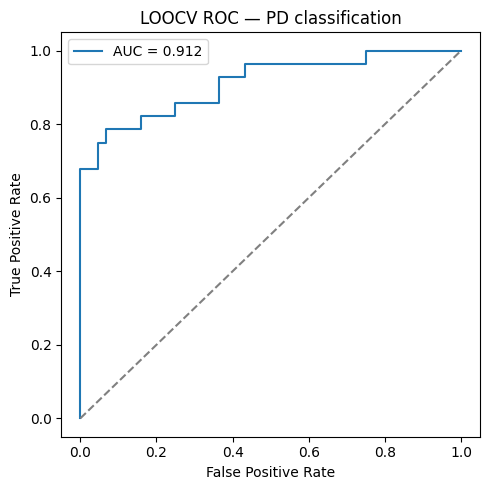

LOOCV AUC: 0.912


In [ ]:
# ===================================================
# STEP 10b: ROC curve from LOOCV predictions
# ===================================================

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_proba_loo = cross_val_predict(rf_final, X_final, y, cv=loo, method="predict_proba")[:, 1]

fpr, tpr, _ = roc_curve(y, y_proba_loo)
auc_score = roc_auc_score(y, y_proba_loo)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LOOCV ROC — PD classification")
plt.legend()
plt.tight_layout()
plt.savefig("ROC_LOOCV.png", dpi=300)
plt.show()

print(f"LOOCV AUC: {auc_score:.3f}")


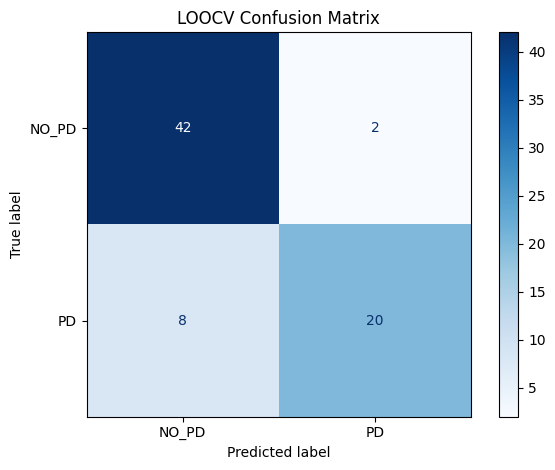

              precision    recall  f1-score   support

       NO_PD       0.84      0.95      0.89        44
          PD       0.91      0.71      0.80        28

    accuracy                           0.86        72
   macro avg       0.87      0.83      0.85        72
weighted avg       0.87      0.86      0.86        72



In [ ]:
# ===================================================
# STEP 10c: Confusion matrix
# ===================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

y_pred_loo = (y_proba_loo >= 0.5).astype(int)
cm = confusion_matrix(y, y_pred_loo)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues")
plt.title("LOOCV Confusion Matrix")
plt.tight_layout()
plt.savefig("ConfusionMatrix_LOOCV.png", dpi=300)
plt.show()

print(classification_report(y, y_pred_loo, target_names=le.classes_))


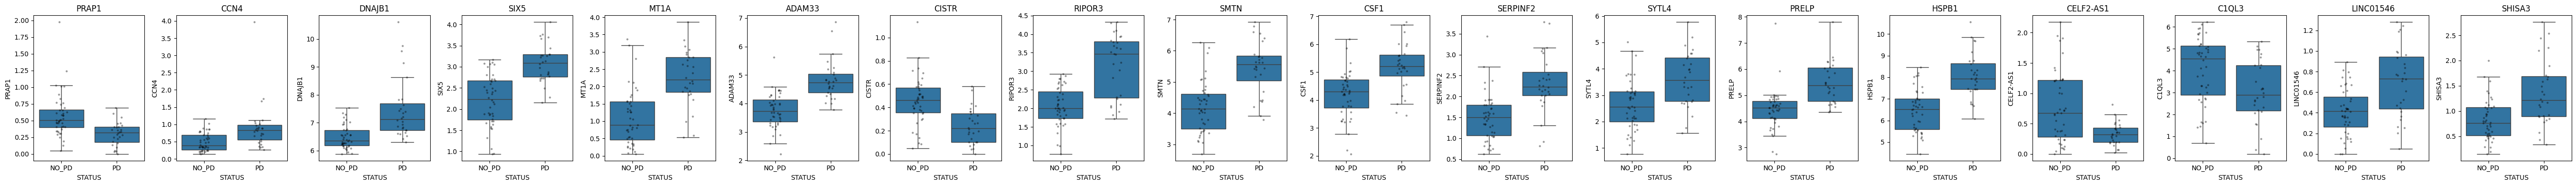

In [ ]:
# ===================================================
# STEP 10d: Per-gene expression by group (boxplot + stripplot)
# ===================================================

import seaborn as sns

plot_df = X_final.copy()
plot_df.columns = [id_to_symbol.get(int(g), g) for g in plot_df.columns]
plot_df["STATUS"] = y_raw.values

gene_cols = [c for c in plot_df.columns if c != "STATUS"]
n_genes = len(gene_cols)

fig, axes = plt.subplots(1, n_genes, figsize=(3 * n_genes, 4))
if n_genes == 1:
    axes = [axes]

for ax, gene in zip(axes, gene_cols):
    sns.boxplot(data=plot_df, x="STATUS", y=gene, ax=ax, showfliers=False)
    sns.stripplot(data=plot_df, x="STATUS", y=gene, ax=ax, color="black", alpha=0.4, size=3)
    ax.set_title(gene)

plt.tight_layout()
plt.savefig("panel_gene_boxplots.png", dpi=300)
plt.show()

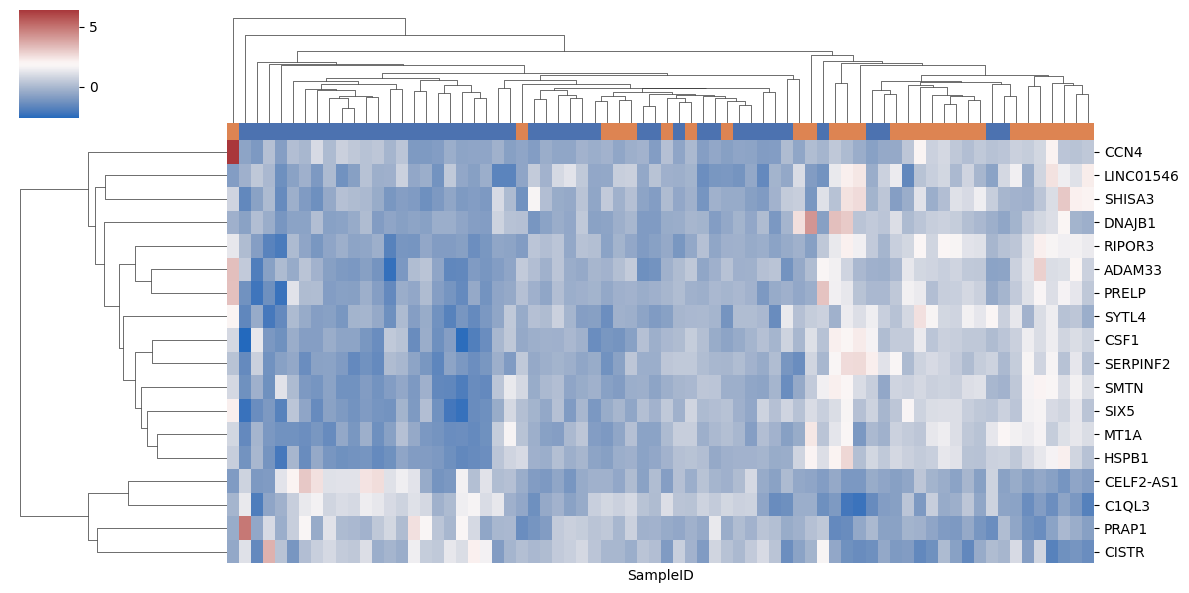

In [ ]:
# ===================================================
# STEP 10e: Clustered heatmap of panel genes
# ===================================================

heat_df = X_final.copy()
heat_df.columns = [id_to_symbol.get(int(g), g) for g in heat_df.columns]

palette = {le.classes_[0]: "#4C72B0", le.classes_[1]: "#DD8452"}
row_colors = y_raw.map(palette)

g = sns.clustermap(
    heat_df.T,              # genes as rows, samples as columns
    col_colors=row_colors.values,
    cmap="vlag",
    z_score=0,               # z-score across samples per gene
    figsize=(12, 6),
    xticklabels=False
)
g.savefig("panel_heatmap.png", dpi=300)
plt.show()

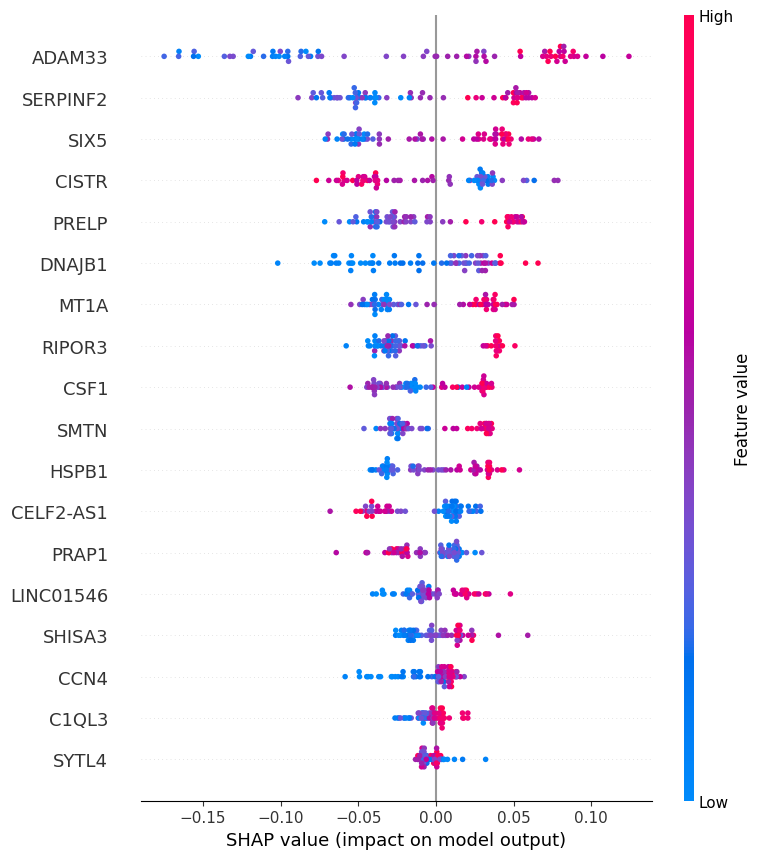

In [ ]:
# ===================================================
# STEP 11: SHAP interpretation (on the final validated panel)
# ===================================================

!pip install shap --break-system-packages
import matplotlib.pyplot as plt
import shap

rf_final.fit(X_final, y)
explainer = shap.TreeExplainer(rf_final)
shap_values = explainer.shap_values(X_final)

shap.summary_plot(
    shap_values[:, :, 1],
    X_final.values,
    feature_names=[id_to_symbol.get(int(g), g) for g in PRIMARY_PANEL],
    show=False          # <-- prevents shap from auto-displaying/clearing the figure
)

plt.tight_layout()
plt.savefig("SHAP_summary_plot.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# ===================================================
# STEP 12: Export all gene lists and validation metrics
# ===================================================

# ---- 1. Top 10 LASSO genes ----
top10_lasso_df = pd.DataFrame({
    "ENTREZID": top10_lasso,
    "SYMBOL": top10_lasso_symbols
})
top10_lasso_df.to_csv("top10_LASSO_genes.csv", index=False)

# ---- 2. Top 10 Boruta genes ----
top10_boruta_df = pd.DataFrame({
    "ENTREZID": top10_boruta,
    "SYMBOL": top10_boruta_symbols
})
top10_boruta_df.to_csv("top10_Boruta_genes.csv", index=False)

# ---- 3. Overlap (genes selected by BOTH top-10 lists) ----
overlap_symbols = [id_to_symbol.get(int(g), g) for g in panel_overlap]
overlap_df = pd.DataFrame({
    "ENTREZID": panel_overlap,
    "SYMBOL": overlap_symbols
})
overlap_df.to_csv("overlap_LASSO_Boruta_genes.csv", index=False)

# ---- 4. Union (genes selected by EITHER method) ----
union_symbols = [id_to_symbol.get(int(g), g) for g in panel_union]
union_df = pd.DataFrame({
    "ENTREZID": panel_union,
    "SYMBOL": union_symbols
})
union_df.to_csv("union_LASSO_Boruta_genes.csv", index=False)

# ---- 5. Primary panel actually used for LOOCV/ROC/SHAP validation ----
primary_panel_df = pd.DataFrame({
    "ENTREZID": PRIMARY_PANEL,
    "SYMBOL": PRIMARY_PANEL_SYMBOLS
})
primary_panel_df.to_csv("ML_final_gene_panel.csv", index=False)

# ---- 6. Validation metrics ----
metrics_df = pd.DataFrame({
    "Metric": ["LOOCV_Accuracy", "LOOCV_AUC"],
    "Value": [scores.mean(), auc_score]
})
metrics_df.to_csv("ML_validation_metrics.csv", index=False)

# ---- 7. One combined master table (method membership per gene) ----
all_ids = sorted(set(top10_lasso) | set(top10_boruta))
master_df = pd.DataFrame({
    "ENTREZID": all_ids,
    "SYMBOL": [id_to_symbol.get(int(g), g) for g in all_ids],
    "In_Top10_LASSO": [g in top10_lasso for g in all_ids],
    "In_Top10_Boruta": [g in top10_boruta for g in all_ids],
    "In_Primary_Panel": [g in PRIMARY_PANEL for g in all_ids],
})
master_df.to_csv("gene_selection_master_table.csv", index=False)

print("\n=== FILES SAVED ===")
print("top10_LASSO_genes.csv")
print("top10_Boruta_genes.csv")
print("overlap_LASSO_Boruta_genes.csv")
print("union_LASSO_Boruta_genes.csv")
print("ML_final_gene_panel.csv")
print("ML_validation_metrics.csv")
print("gene_selection_master_table.csv")

print("\n=== SUMMARY ===")
print(f"Top 10 LASSO genes:  {top10_lasso_symbols}")
print(f"Top 10 Boruta genes: {top10_boruta_symbols}")
print(f"Overlap ({len(panel_overlap)}): {overlap_symbols}")
print(f"Union ({len(panel_union)}): {union_symbols}")
print(f"Primary validated panel ({len(PRIMARY_PANEL)} genes): {PRIMARY_PANEL_SYMBOLS}")
print(f"LOOCV Accuracy: {scores.mean():.3f} | LOOCV AUC: {auc_score:.3f}")


=== FILES SAVED ===
top10_LASSO_genes.csv
top10_Boruta_genes.csv
overlap_LASSO_Boruta_genes.csv
union_LASSO_Boruta_genes.csv
ML_final_gene_panel.csv
ML_validation_metrics.csv
gene_selection_master_table.csv

=== SUMMARY ===
Top 10 LASSO genes:  ['ADAM33', 'DNAJB1', 'C1QL3', 'CELF2-AS1', 'CISTR', 'CCN4', 'SYTL4', 'SHISA3', 'PRAP1', 'LINC01546']
Top 10 Boruta genes: ['ADAM33', 'SERPINF2', 'SIX5', 'PRELP', 'HSPB1', 'MT1A', 'SMTN', 'DNAJB1', 'RIPOR3', 'CSF1']
Overlap (2): ['DNAJB1', 'ADAM33']
Union (18): ['PRAP1', 'CCN4', 'DNAJB1', 'SIX5', 'MT1A', 'ADAM33', 'CISTR', 'RIPOR3', 'SMTN', 'CSF1', 'SERPINF2', 'SYTL4', 'PRELP', 'HSPB1', 'CELF2-AS1', 'C1QL3', 'LINC01546', 'SHISA3']
Primary validated panel (18 genes): ['PRAP1', 'CCN4', 'DNAJB1', 'SIX5', 'MT1A', 'ADAM33', 'CISTR', 'RIPOR3', 'SMTN', 'CSF1', 'SERPINF2', 'SYTL4', 'PRELP', 'HSPB1', 'CELF2-AS1', 'C1QL3', 'LINC01546', 'SHISA3']
LOOCV Accuracy: 0.861 | LOOCV AUC: 0.912
